# Data Tranformation(DGS Reduction)

# Load data as Scipp DataArray

In [1]:
import os
import sys
import scipp as sc
import mcstastox as mx

parent = os.path.dirname(os.getcwd())
sys.path.append(parent)

file_path = parent + "/runs/LET_vanad"

with mx.Read(file_path) as mcstas_data:
    scipp_data_group = mcstas_data.export_scipp(
        source_name="SourceMantid",
        sample_name="iso_samp",
    )
display(scipp_data_group)

DataGroup(sizes={'pixel_id': None, 'panel_id': 1, 'pixel': 2}, keys=[
    events: DataArray({'pixel_id': 25886}),
    positions: Variable({'pixel_id': 30056}),
    bank_ids: Variable({'panel_id': 1, 'pixel': 2}),
    bank_names: Variable({'panel_id': 1}),
])

In [2]:
events_binned = scipp_data_group["events"]
display(events_binned)

<scipp.DataArray>
Dimensions: Sizes[pixel_id:25886, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30053, 30054]
* position                  vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.3436, 1.98529, 22.4005), (2.30641, 1.98529, 22.3674)]
* sample_position           vector3              [m]  ()  (0, 0, 25)
* source_position           vector3              [m]  ()  (0, 0, 0)
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

# Read in Monitor data

In [3]:
import mcstasscript as ms
from reduction.dgs_reduction import monitor_single_pulse

mcstas_data = ms.load_data(file_path)
presample_monitor_data = ms.name_search("Monitor6", mcstas_data)
monitor_data = monitor_single_pulse(presample_monitor_data)

with mx.Read(file_path) as mcstas_data:
    presample_monitor_position = mcstas_data.get_global_component_coordinates(
        component_name="Monitor6"
    )

monitor_data.coords["presample_monitor_position"] = sc.vector(
    value=presample_monitor_position, unit="m"
)
monitor_data.coords["source_position"] = events_binned.coords.pop("source_position")
monitor_data.coords["sample_position"] = events_binned.coords.pop("sample_position")

# Calculate Ei per RRM

<scipp.DataArray>
Dimensions: Sizes[rrm:1, ]
Coordinates:
* ei                        float64            [meV]  (rrm)  [3.67905]
  presample_monitor_position  vector3              [m]  ()  (0, 0, 23.505)
  sample_position           vector3              [m]  ()  (0, 0, 25)
  source_position           vector3              [m]  ()  (0, 0, 0)
  time_on_monitor           float64              [s]  (rrm)  [0.0280169]
* time_on_sample            float64              [s]  (rrm)  [0.0297989]
* vec_ki                    vector3           [1/Å]  (rrm)  [(0, 0, 1.33248)]
* vi                        float64            [m/s]  (rrm)  [838.957]
Data:
                            float64         [counts]  (rrm)  [41770.6]

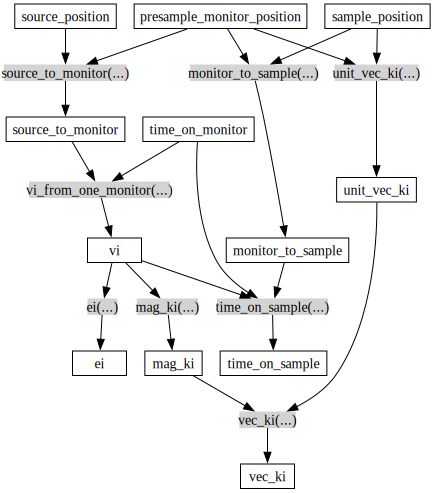

In [ ]:
from dgs_reduction import calculate_ei

monitor_data = monitor_data.transform_coords(
    ["ei", "time_on_sample", "vec_ki","vi"], graph=calculate_ei, keep_intermediate=False
)
display(monitor_data)
sc.show_graph(calculate_ei)

In [5]:
sample_to_detectors = sc.norm(scipp_data_group["positions"] - monitor_data.coords['sample_position'])
sample_to_detectors

<scipp.Variable> (pixel_id: 30056)    float64              [m]  [4.02385, 4.02385, ..., 4.02385, 4.02385]

In [ ]:
sample_to_detectors / monitor_data.coords["vi"] + monitor_data.coords["time_on_sample"]


<scipp.Variable> (pixel_id: 30056, rrm: 1)    float64              [s]  [0.00479625, 0.00479625, ..., 0.00479625, 0.00479625]

In [7]:
events_binned

<scipp.DataArray>
Dimensions: Sizes[pixel_id:25886, ]
Coordinates:
* pixel_id                    int64  [dimensionless]  (pixel_id)  [0, 1, ..., 30053, 30054]
* position                  vector3              [m]  (pixel_id)  [(-2.23064, -1.98529, 27.6971), (-2.19208, -1.98529, 27.7285), ..., (2.3436, 1.98529, 22.4005), (2.30641, 1.98529, 22.3674)]
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='events', content=DataArray(
          dims=(events: 59921),
          data=float64[counts],
          coords={'t':float64[s]})

# Group by pixel_id to fill in the missing pixels
This step is only necessary when some detectors have not recorded any counts.

In [8]:

events = events_binned.group(sc.arange(det_pos.dim, 0, det_pos.size))
# McStas provides absolute time, not time of flight, rename
events.bins.coords["tof"] = events.bins.coords.pop("t")
display(events)

NameError: name 'det_pos' is not defined

Add detecotr positions back as coordinates

In [ ]:
events.coords["detector_positions"] = det_pos
display(events)

# Separate events based on the sub-pulse they belong to
# rewrite here

In [ ]:
import numpy as np
import scipp.constants as consts


def energy_to_momentum(en):
    k = sc.sqrt(2 * consts.m_n * en) / consts.hbar
    return k.to(unit="1/Å")


def energy_to_speed(en):
    v = sc.sqrt(2 * en / consts.m_n)
    return v.to(unit="m/s")


def speed_to_energy(v):
    en = 0.5 * consts.m_n * v**2
    return en.to(unit="meV")


def determine_INS_windows(events, energy_transfer_ratio=(-0.9, 0.9)):
    """Check allowed range to avoid frame overlap.
    Keep E = Ei - Ef = ±0.8*Ei by default."""

    r_gain, r_loss = 1 / (1 - np.array(energy_transfer_ratio))

    ei = events.coords["ei"]
    time_on_sample = events.coords["time_on_sample"]
    sample_to_detectors = events.coords["sample_to_detectors"]

    ef_gain = ei / r_gain
    ef_loss = ei / r_loss

    vf_gain = energy_to_speed(ef_gain)
    vf_loss = energy_to_speed(ef_loss)

    t_gain = time_on_sample + sample_to_detectors / vf_gain
    t_loss = time_on_sample + sample_to_detectors / vf_loss

    # TODO check for overlap, modify t_gain/t_loss
    # LET has a source frequency of 10 Hz
    pass

    vf_gain = sample_to_detectors / (t_gain - time_on_sample)
    vf_loss = sample_to_detectors / (t_loss - time_on_sample)

    ef_gain = speed_to_energy(vf_gain)
    ef_loss = speed_to_energy(vf_loss)

    energy_transfer_ratio = (1 - ef_gain / ei, 1 - ef_loss / ei)

    return events


determine_INS_windows(events, energy_transfer_ratio=(-0.8, 0.8))

# Calculate extrema of kf (per detector, per ei/sub-pulse)

In [ ]:
from dgs_reduction import calculate_ef

# ±0.8 Ei are kept
events.coords["energy_transfer_ratio"] = sc.array(dims=["pair"], values=[-0.8, 0.8])

events = events.transform_coords(
    ["energy_transfer_ratio"],
    graph=calculate_ef,
    keep_intermediate=False,
)

display(events)
sc.show_graph(calculate_ef)

# ei = events.coords['ei']
# ef_m =  ei / ei_ef_ratio[0]
# ef_M =  ei / ei_ef_ratio[1]

# kf_m = energy_to_momentum(ef_m)
# kf_M = energy_to_momentum(ef_M)

In [ ]:
# from reduction.dgs_reduction import calculate_ei

# events = events.transform_coords(
#     ["ei", "mag_Q", "qx", "qy", "qz"], graph=calculate_ei, keep_intermediate=False
# )
# display(events)
# sc.show_graph(calculate_ei)

# Access and calculate detector trajectory endpoints

In [ ]:
sample_position = events_binned.coords["sample_position"]
pixel_vec = scipp_data_group["positions"] - sample_position
pixel_vec = pixel_vec / sc.norm(pixel_vec)

Q_max = ki.to(unit="1/Å") - (pixel_vec * max_kf)
Q_min = ki.to(unit="1/Å") - (pixel_vec * min_kf)

kf_max = sc.broadcast(max_kf, dims=Q_max.dims, shape=Q_max.shape)
kf_min = sc.broadcast(min_kf, dims=Q_min.dims, shape=Q_min.shape)

kf_min

# Calculate detector solid angles dOmega (detector counts/monitor counts)

In [ ]:
scale_factor = (
    events_binned.data.sum()
    / events_binned.coords["monitor_counts"]
    * (4 * sc.constants.pi)
)
dOmega = (
    events_binned.bins.sum().data
    / events_binned.coords["monitor_counts"]
    * (4 * sc.constants.pi)
)
events_binned.coords["dOmega"] = dOmega

# Generate 4D grid for histogramming

In [ ]:
bins = generate_bins(
    qx=(-2, 1.5, 0.1),
    qy=(-0.1, 0.1),
    qz=(-1, 3.0, 0.1),
    en=(-0.2, 0.2),
)

# convert energy to kf

In [ ]:
hbar = sc.constants.hbar
m_n = sc.constants.neutron_mass

kf_array = (
    (sc.sqrt(2 * m_n * (ei[0] - bins["en"])) / hbar)
    .to(unit="1/Å")
    .rename_dims({"en": "mag_kf"})
)
bins["mag_kf"] = kf_array[~sc.isnan(kf_array)]
bins["mag_kf"] = sc.sort(bins["mag_kf"], key="mag_kf")

edges = {key: bins[key] for key in ("qx", "qy", "qz", "mag_kf")}
display(edges)

# Calculate normalization factor per pixel

In [ ]:
hbar = sc.constants.hbar
m_n = sc.constants.neutron_mass


def _calc_en_from_kf_endpoints(kf_in, kf_out):
    en = hbar**2 / m_n * 0.5 * ((kf_in**2 - kf_out**2) * sc.Unit("1/Å^2"))
    return sc.abs(en).to(unit="meV")

In [ ]:
from voxel_traversal_4d import voxel_traversal_4d

# create norm_array
dims = list(edges.keys())
shape = [var.sizes[dim] - 1 for dim, var in edges.items()]

norm_arr = sc.zeros(
    dims=dims,
    shape=shape,
    unit=sc.Unit("meV^"),
)

edges_arr = [edge.values for edge in edges.values()]

# loop over all pixels

for pixel in range(Q_max.sizes["pixel_id"]):
    # calculate intersections
    start = np.concatenate(
        [Q_min["pixel_id", pixel].values[0], kf_min["pixel_id", pixel].values]
    )
    end = np.concatenate(
        [Q_max["pixel_id", pixel].values[0], kf_max["pixel_id", pixel].values]
    )
    for idx, p_in, p_out in voxel_traversal_4d(start, end, edges_arr):
        i, j, k, l = idx
        *_, kf_in = p_in
        *_, kf_out = p_out
        dE_i = _calc_en_from_kf_endpoints(kf_in, kf_out)

        # solid angle
        dOmega_i = dOmega["pixel_id", pixel]

        # sum
        norm_arr["qx", i]["qy", j]["qz", k]["mag_kf", l] += dE_i * dOmega_i

# Histogram data

In [ ]:
%matplotlib widget

data_hist = sc.bin(events_binned.data, **edges).hist()
display(data_hist)
pp.plot(
    data_hist.squeeze().transpose(),
    coords=["qx", "qz"],
    grid=True,
    cmap="turbo",
)

# Data divided by normalization factor

In [ ]:
data_hist.squeeze()

In [ ]:
norm_arr

In [ ]:
# norm_factor = events.bins.concat().value.copy()
# norm_factor.data = sc.bins_like(events, events.coords["dOmega"]).bins.concat().value

# norm_hist = sc.bin(norm_factor, **edges).hist()

pp.plot(
    (data_hist.squeeze().transpose()) / norm_arr.squeeze(),
    coords=["qx", "qz"],
    grid=True,
    cmap="turbo",
    vmin=0,
    vmax=5e5,
)